
# XQuality — Incremental layer contribution analysis

This notebook does **not** try to prove that every layer monotonically improves final F1.

Instead, it asks a cleaner ablation question:

> What does each layer add compared with the previous cumulative evidence pool?

It measures:

1. **New information added per layer**
2. **Reinforced information already seen in earlier layers**
3. **New information that aligns with gold triples**
4. **New information that aligns with the native NeoOLAF final export**
5. **New uncertain / reference-unmatched information**
6. **New likely noise**: reference-unmatched triples that appear only once and are not reused by later layers
7. **Cumulative coverage of the native final export**

This is designed to answer:

> Does the cumulative layer evidence increasingly contain the material needed to produce the final NeoOLAF KG?


In [1]:

from pathlib import Path
import sys
import json
import re
import math
import unicodedata
from difflib import SequenceMatcher
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)


def find_project_root(start=None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src" / "neoolaf").exists():
            return p
    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "examples" / "XQualityMachine32").exists():
            return p
    raise RuntimeError("Could not find NeoOLAF project root. Run this notebook from inside the NeoOLAF repository.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EXAMPLE_ROOT = PROJECT_ROOT / "examples" / "XQualityMachine32"
RUNS_ROOT = EXAMPLE_ROOT / "runs"

PREFIX_RUNS_DIR = RUNS_ROOT / "prefix_stop_after_layer_llm_finalization_exact_eval"
GOLD_PATH = PROJECT_ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"

# Leave as None to auto-detect. If auto-detection chooses the wrong folder, set manually.
FINAL_EXPORT_DIR = None

OUTPUT_DIR = RUNS_ROOT / "incremental_layer_contribution_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREFIX_RUNS_DIR:", PREFIX_RUNS_DIR)
print("GOLD_PATH:", GOLD_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert PREFIX_RUNS_DIR.exists(), f"Missing prefix run directory: {PREFIX_RUNS_DIR}"
assert GOLD_PATH.exists(), f"Missing gold file: {GOLD_PATH}"


PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
PREFIX_RUNS_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval
GOLD_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Examples\XQuality_all_triplets_flat_en.json
OUTPUT_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis


c:\Users\henri\Documents\git\post-doc\neoolafvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### v2 fix

This version fixes gold loading for the real XQuality flat JSON schema:

`Node 1`, `RELATION`, `Node 2`

It also tries the official NeoOLAF gold loader before falling back to direct parsing. The sanity check should now report roughly **439 gold triples** instead of zero.


## Configuration

The matching below is **not the official NeoOLAF evaluator**. It is an **incremental alignment analysis**.

It uses predicate-aware approximate matching to decide whether two triples are close enough to represent the same information.

You can tune the thresholds below. If matching is too strict, cumulative final-export coverage will be underestimated. If it is too loose, uncertain/noise will be underestimated.


In [2]:

# Matching thresholds.
SUBJECT_SIM_THRESHOLD = 0.72
OBJECT_SIM_THRESHOLD = 0.68

# Approximate clustering settings.
ENABLE_APPROX_CLUSTERING = True
CLUSTER_SUBJECT_SIM_THRESHOLD = 0.82
CLUSTER_OBJECT_SIM_THRESHOLD = 0.78

# If True, same-predicate matching only. Recommended.
REQUIRE_SAME_PREDICATE = True

# Minimum triples in a prefix folder.
MIN_TRIPLES_PER_PREFIX = 1

# Whether to require COMPLETED.json marker for prefix folders.
# Set False if older generated folders do not have marker but have triples.json.
STRICT_COMPLETED_MARKER = False

# If True, unmatched clusters that occur in only one layer are counted as likely noise.
COUNT_SINGLE_LAYER_UNMATCHED_AS_LIKELY_NOISE = True

print("Config loaded.")


Config loaded.


## Triple loading utilities

In [3]:

def load_json_any(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def unwrap_triple_container(obj):
    """Return a list-like collection of triples from common NeoOLAF/prefix JSON shapes."""
    if obj is None:
        return []
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for key in [
            "triples",
            "relations",
            "candidate_triples",
            "candidate_relation_assertions",
            "kg",
            "data",
            "items",
        ]:
            value = obj.get(key)
            if isinstance(value, list):
                return value
        # Sometimes dictionary values themselves are triples.
        if all(isinstance(v, dict) for v in obj.values()):
            return list(obj.values())
    return []


def first_nonempty(*values):
    for v in values:
        if v is not None:
            s = str(v).strip()
            if s and s.lower() not in {"none", "null", "nan", "?"}:
                return s
    return ""


def normalize_predicate_label(x):
    s = first_nonempty(x)
    if not s:
        return ""
    # If relation has "Pxxx : label", keep the label part when useful.
    if ":" in s:
        left, right = s.split(":", 1)
        if right.strip():
            s = right.strip()
    s = s.upper().strip()
    s = re.sub(r"[^A-Z0-9]+", "_", s).strip("_")

    aliases = {
        "CAUSE": "CAUSES",
        "CAUSES": "CAUSES",
        "CAUSED_BY": "CAUSES",
        "TRIGGER": "TRIGGERS",
        "TRIGGERS": "TRIGGERS",
        "TRIGGERED_BY": "TRIGGERS",
        "REQUIRE": "REQUIRES",
        "REQUIRES": "REQUIRES",
        "REQUIRED_BY": "REQUIRES",
        "REFERENCE": "REFERENCES",
        "REFERENCES": "REFERENCES",
        "REFERS_TO": "REFERENCES",
        "HANDLED_BY": "HANDLED_BY",
        "HANDLEDBY": "HANDLED_BY",
        "HANDLER": "HANDLED_BY",
    }
    return aliases.get(s, s)


def triple_from_record(rec, default_source=""):
    """Normalize many possible triple schemas into a common dict."""
    if not isinstance(rec, dict):
        return None

    subject = first_nonempty(
        rec.get("subject"),
        rec.get("head"),
        rec.get("source"),
        rec.get("subject_label"),
        rec.get("head_label"),
        rec.get("source_label"),
        rec.get("s"),
    )
    predicate = first_nonempty(
        rec.get("predicate"),
        rec.get("relation"),
        rec.get("relation_label"),
        rec.get("predicate_label"),
        rec.get("p"),
    )
    obj = first_nonempty(
        rec.get("object"),
        rec.get("tail"),
        rec.get("target"),
        rec.get("object_label"),
        rec.get("tail_label"),
        rec.get("target_label"),
        rec.get("o"),
    )

    if not subject or not predicate or not obj:
        return None

    evidence = first_nonempty(
        rec.get("evidence"),
        rec.get("support"),
        rec.get("source_text"),
        rec.get("provenance"),
        rec.get("context"),
        rec.get("sentence"),
        rec.get("chunk_text"),
    )

    confidence = rec.get("confidence", rec.get("score", rec.get("support_score", None)))
    try:
        confidence = float(confidence) if confidence is not None else None
    except Exception:
        confidence = None

    return {
        "subject": subject,
        "predicate": normalize_predicate_label(predicate),
        "object": obj,
        "evidence": evidence,
        "confidence": confidence,
        "raw": rec,
        "source_file": default_source,
    }


def load_triples_from_file(path: Path):
    try:
        obj = load_json_any(path)
    except Exception as e:
        print("Could not read", path, "->", repr(e))
        return []
    rows = []
    for rec in unwrap_triple_container(obj):
        t = triple_from_record(rec, default_source=str(path))
        if t is not None:
            rows.append(t)
    return rows


def load_triples_from_folder(folder: Path):
    candidates = [
        "triples.json",
        "kg_inferred.json",
        "kg.json",
        "kg_local.json",
        "relations.json",
        "candidate_triples.json",
    ]
    for name in candidates:
        path = folder / name
        if path.exists():
            triples = load_triples_from_file(path)
            if triples:
                return triples, path
    # fallback: try all json files in folder
    for path in sorted(folder.glob("*.json")):
        triples = load_triples_from_file(path)
        if triples:
            return triples, path
    return [], None


def count_triples_in_folder(folder: Path):
    triples, _ = load_triples_from_folder(Path(folder))
    return len(triples)


## Text normalization and approximate matching

In [4]:

STOPWORDS = {
    "the", "a", "an", "of", "to", "and", "or", "for", "in", "on", "with", "by", "is", "are", "be", "as",
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "ou", "pour", "dans", "sur", "avec", "par",
    "message", "alarm", "alarme", "error", "fault", "warning", "code",
}


def strip_accents(s):
    return "".join(
        c for c in unicodedata.normalize("NFKD", str(s))
        if not unicodedata.combining(c)
    )


def norm_text(s):
    s = strip_accents(str(s).lower())
    s = re.sub(r"[_/\\\-]+", " ", s)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def tokens(s):
    return [t for t in norm_text(s).split() if t and t not in STOPWORDS]


def token_jaccard(a, b):
    ta, tb = set(tokens(a)), set(tokens(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)


def token_containment(a, b):
    ta, tb = set(tokens(a)), set(tokens(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / min(len(ta), len(tb))


def char_ngram_jaccard(a, b, n=3):
    a = norm_text(a)
    b = norm_text(b)
    if len(a) < n or len(b) < n:
        return 0.0
    ga = {a[i:i+n] for i in range(len(a)-n+1)}
    gb = {b[i:i+n] for i in range(len(b)-n+1)}
    if not ga or not gb:
        return 0.0
    return len(ga & gb) / len(ga | gb)


def text_similarity(a, b):
    a0, b0 = norm_text(a), norm_text(b)
    if not a0 or not b0:
        return 0.0
    if a0 == b0:
        return 1.0

    seq = SequenceMatcher(None, a0, b0).ratio()
    jac = token_jaccard(a0, b0)
    cont = token_containment(a0, b0)
    ch3 = char_ngram_jaccard(a0, b0, n=3)

    # For short labels, containment can be too optimistic, so cap it a bit unless sequence also agrees.
    if min(len(tokens(a0)), len(tokens(b0))) <= 2 and seq < 0.60:
        cont = min(cont, 0.65)

    return max(seq, jac, cont, ch3)


def exact_triple_key(t):
    return (
        normalize_predicate_label(t.get("predicate", "")),
        norm_text(t.get("subject", "")),
        norm_text(t.get("object", "")),
    )


def triple_text(t):
    return f"{t.get('subject','')} -- {t.get('predicate','')} --> {t.get('object','')}"


def triple_match_score(a, b):
    pa = normalize_predicate_label(a.get("predicate", ""))
    pb = normalize_predicate_label(b.get("predicate", ""))
    if REQUIRE_SAME_PREDICATE and pa != pb:
        return {
            "match": False,
            "predicate_equal": False,
            "subject_sim": 0.0,
            "object_sim": 0.0,
            "score": 0.0,
        }

    ss = text_similarity(a.get("subject", ""), b.get("subject", ""))
    os = text_similarity(a.get("object", ""), b.get("object", ""))
    score = min(ss, os)
    return {
        "match": (pa == pb or not REQUIRE_SAME_PREDICATE) and ss >= SUBJECT_SIM_THRESHOLD and os >= OBJECT_SIM_THRESHOLD,
        "predicate_equal": pa == pb,
        "subject_sim": ss,
        "object_sim": os,
        "score": score,
    }


## Discover prefix folders and native final export

In [5]:

def parse_stop_index(folder_name):
    m = re.search(r"prefix_stop_after_(\d+)_", folder_name)
    return int(m.group(1)) if m else None


def discover_prefix_folders(root: Path):
    rows = []
    for folder in sorted(x for x in Path(root).iterdir() if x.is_dir()):
        stop_index = parse_stop_index(folder.name)
        if stop_index is None:
            continue
        if STRICT_COMPLETED_MARKER and not (folder / "COMPLETED.json").exists():
            continue
        triples, triple_file = load_triples_from_folder(folder)
        if len(triples) < MIN_TRIPLES_PER_PREFIX:
            continue
        rows.append({
            "stop_index": stop_index,
            "layer_name": folder.name,
            "folder": folder,
            "triple_file": triple_file,
            "triple_count": len(triples),
        })
    rows = sorted(rows, key=lambda r: r["stop_index"])
    return rows


def discover_final_export_dir():
    if FINAL_EXPORT_DIR is not None:
        p = Path(FINAL_EXPORT_DIR)
        assert p.exists(), f"Manual FINAL_EXPORT_DIR does not exist: {p}"
        return p

    candidates = []
    for path in RUNS_ROOT.rglob("*"):
        if not path.is_file():
            continue
        if path.name not in {"kg_inferred.json", "kg.json", "kg_local.json", "triples.json"}:
            continue
        s = str(path).lower()
        if "prefix_stop_after" in s:
            continue
        if "robust_eval" in s or "cumulative" in s or "olaf" in s:
            continue
        folder = path.parent
        triples = load_triples_from_file(path)
        n = len(triples)
        if n == 0:
            continue
        # prefer something near the known final export size 226
        score = abs(n - 226)
        candidates.append((score, -path.stat().st_mtime, n, folder, path))

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]))
    print("Top final export candidates:")
    for score, neg_mtime, n, folder, path in candidates[:10]:
        print(f"  n={n:4d} score={score:4d} file={path}")

    return candidates[0][3]


prefix_folders = discover_prefix_folders(PREFIX_RUNS_DIR)
print(f"Found {len(prefix_folders)} prefix folders")
display(pd.DataFrame([
    {
        "stop_index": r["stop_index"],
        "layer_name": r["layer_name"],
        "triple_count": r["triple_count"],
        "folder": str(r["folder"]),
        "triple_file": str(r["triple_file"]),
    }
    for r in prefix_folders
]))

FINAL_EXPORT_DIR_RESOLVED = discover_final_export_dir()
print("Selected FINAL_EXPORT_DIR:", FINAL_EXPORT_DIR_RESOLVED)

if FINAL_EXPORT_DIR_RESOLVED is None:
    print("WARNING: no native final export detected. Native-final alignment metrics will be skipped.")
else:
    final_triples, final_file = load_triples_from_folder(FINAL_EXPORT_DIR_RESOLVED)
    print("Native final export triple count:", len(final_triples))
    print("Native final export file:", final_file)
    if len(final_triples) != 226:
        print("WARNING: selected final export is not 226 triples. Manually set FINAL_EXPORT_DIR if this is wrong.")


Found 13 prefix folders


,stop_index,layer_name,triple_count,folder,triple_file
0,0,prefix_stop_after_00_layer00_preprocessing,124,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_00_layer00_preprocessing,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_00_layer00_preprocessing\tri...
1,1,prefix_stop_after_01_layer01_linguistic_expression_extraction,841,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_01_layer01_linguistic_expres...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_01_layer01_linguistic_expres...
2,2,prefix_stop_after_02_layer02_candidate_enrichment,1428,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_02_layer02_candidate_enrichment,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_02_layer02_candidate_enrichm...
3,3,prefix_stop_after_03_layer03_candidate_typing_resolution,1812,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_03_layer03_candidate_typing_...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_03_layer03_candidate_typing_...
4,4,prefix_stop_after_04_layer04_candidate_relation_extraction,2668,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_04_layer04_candidate_relatio...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_04_layer04_candidate_relatio...
5,5,prefix_stop_after_05_layer05_candidate_triple_generation,2657,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_05_layer05_candidate_triple_...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_05_layer05_candidate_triple_...
6,6,prefix_stop_after_06_layer06_concept_relation_induction,2742,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_06_layer06_concept_relation_...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_06_layer06_concept_relation_...
7,7,prefix_stop_after_07_layer07_hierarchisation,2642,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_07_layer07_hierarchisation,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_07_layer07_hierarchisation\t...
8,8,prefix_stop_after_08_layer08_axiom_schemata_extraction,2881,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_08_layer08_axiom_schemata_ex...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_after_layer_llm_finalization_exact_eval\prefix_stop_after_08_layer08_axiom_schemata_ex...
9,9,prefix_stop_after_09_layer09_general_axiom_extraction,3121,C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\prefix_stop_a

Selected FINAL_EXPORT_DIR: None


## Load gold and final references

In [6]:

# Robust gold loader.
# This fixes the XQuality gold format with columns:
#   "Node 1", "RELATION", "Node 2"
# It also tries the official NeoOLAF gold loader first when available.

PROFILE_NAME = globals().get("PROFILE_NAME", "xquality_relaxed_recall")


def _as_dict(obj):
    if isinstance(obj, dict):
        return obj
    d = {}
    for name in dir(obj):
        if name.startswith("_"):
            continue
        try:
            value = getattr(obj, name)
        except Exception:
            continue
        if callable(value):
            continue
        d[name] = value
    return d


def _get_field(obj, *names):
    if isinstance(obj, dict):
        for name in names:
            if name in obj:
                v = obj.get(name)
                if v is not None and str(v).strip() not in {"", "?", "None", "null", "nan"}:
                    return v
    else:
        for name in names:
            if hasattr(obj, name):
                try:
                    v = getattr(obj, name)
                except Exception:
                    continue
                if v is not None and str(v).strip() not in {"", "?", "None", "null", "nan"}:
                    return v
    return None


def _dedupe_triples(triples):
    seen = set()
    out = []
    for t in triples:
        if not t:
            continue
        k = exact_triple_key(t)
        if k not in seen:
            seen.add(k)
            out.append(t)
    return out


def _entity_id_to_label_map(artifact):
    out = {}
    entities = getattr(artifact, "entities", []) or []
    for ent in entities:
        eid = _get_field(ent, "id", "entity_id", "uid", "identifier")
        label = _get_field(ent, "label", "text", "name", "canonical_label", "surface", "value")
        if eid is not None and label is not None:
            out[str(eid)] = str(label)
    return out


def _resolve_entity_ref(value, id_to_label):
    if value is None:
        return ""
    s = str(value).strip()
    if not s:
        return ""
    return id_to_label.get(s, s)


def _triple_from_eval_relation(rel, id_to_label=None, default_source="official_gold_loader"):
    id_to_label = id_to_label or {}
    subject = _get_field(rel,
        "subject", "head", "source", "subject_label", "head_label", "source_label",
        "subj", "node1", "Node 1"
    )
    predicate = _get_field(rel,
        "predicate", "relation", "relation_label", "predicate_label", "type", "label",
        "RELATION"
    )
    obj = _get_field(rel,
        "object", "tail", "target", "object_label", "tail_label", "target_label",
        "obj", "node2", "Node 2"
    )
    subject = _resolve_entity_ref(subject, id_to_label)
    obj = _resolve_entity_ref(obj, id_to_label)
    if not subject or not predicate or not obj:
        return None
    return {
        "subject": subject,
        "predicate": normalize_predicate_label(predicate),
        "object": obj,
        "evidence": "",
        "confidence": None,
        "raw": _as_dict(rel),
        "source_file": default_source,
    }


def _iter_possible_records(obj):
    """Flatten common JSON containers into record dictionaries/lists."""
    if obj is None:
        return []
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        rows = []
        # first try known list containers
        for key in [
            "triples", "relations", "gold", "gold_triples", "items", "data", "records",
            "candidate_triples", "candidate_relation_assertions",
        ]:
            value = obj.get(key)
            if isinstance(value, list):
                rows.extend(value)
        if rows:
            return rows
        # if values are records
        if all(isinstance(v, dict) for v in obj.values()):
            return list(obj.values())
    return []


def _triple_from_xquality_gold_record(rec, default_source=""):
    if not isinstance(rec, dict):
        return None
    # The real flat XQuality JSON has exactly these fields:
    # {"Node 1": ..., "RELATION": ..., "Node 2": ...}
    subject = first_nonempty(
        rec.get("Node 1"), rec.get("node_1"), rec.get("node1"), rec.get("source"),
        rec.get("subject"), rec.get("head"), rec.get("source_label"), rec.get("subject_label"), rec.get("head_label"),
    )
    predicate = first_nonempty(
        rec.get("RELATION"), rec.get("relation"), rec.get("predicate"),
        rec.get("relation_label"), rec.get("predicate_label"),
    )
    obj = first_nonempty(
        rec.get("Node 2"), rec.get("node_2"), rec.get("node2"), rec.get("target"),
        rec.get("object"), rec.get("tail"), rec.get("target_label"), rec.get("object_label"), rec.get("tail_label"),
    )
    if not subject or not predicate or not obj:
        return None
    return {
        "subject": subject,
        "predicate": normalize_predicate_label(predicate),
        "object": obj,
        "evidence": first_nonempty(rec.get("evidence"), rec.get("support"), rec.get("source_text")),
        "confidence": None,
        "raw": rec,
        "source_file": default_source,
    }


def load_gold_triples(gold_path: Path):
    gold_path = Path(gold_path)
    triples = []

    # 1) Try the official NeoOLAF loader. This is the safest when available.
    try:
        from neoolaf.evaluation.runners.evaluate_layer_state import load_xquality_gold_any, gold_to_artifact
        from neoolaf.evaluation.profiles.registry import get_profile

        gold = load_xquality_gold_any(gold_path)
        profile = get_profile(PROFILE_NAME)
        artifact = gold_to_artifact(gold, profile)
        id_to_label = _entity_id_to_label_map(artifact)
        rels = getattr(artifact, "relations", []) or []
        for rel in rels:
            t = _triple_from_eval_relation(rel, id_to_label=id_to_label, default_source="official_gold_loader")
            if t is not None:
                triples.append(t)
        triples = _dedupe_triples(triples)
        if triples:
            print(f"Loaded gold with official NeoOLAF loader: {len(triples)} triples")
            return triples
        print("Official NeoOLAF gold loader returned zero usable triples; falling back to direct JSON parser.")
    except Exception as e:
        print("Official NeoOLAF gold loader unavailable/failed; falling back to direct JSON parser:", repr(e))

    # 2) Direct parser for JSON/XQuality flat formats.
    obj = load_json_any(gold_path)
    for rec in _iter_possible_records(obj):
        t = _triple_from_xquality_gold_record(rec, default_source=str(gold_path))
        if t is not None:
            triples.append(t)

    # 3) Last fallback: previous generic triple parser.
    if not triples:
        for rec in unwrap_triple_container(obj):
            t = triple_from_record(rec, default_source=str(gold_path))
            if t is not None:
                triples.append(t)

    triples = _dedupe_triples(triples)
    return triples


gold_triples = load_gold_triples(GOLD_PATH)
print("Gold triples loaded:", len(gold_triples))
if len(gold_triples) == 0:
    print("GOLD_PATH:", GOLD_PATH)
    try:
        sample_obj = load_json_any(GOLD_PATH)
        print("Gold root type:", type(sample_obj))
        if isinstance(sample_obj, list) and sample_obj:
            print("First gold row keys:", list(sample_obj[0].keys()) if isinstance(sample_obj[0], dict) else type(sample_obj[0]))
            print("First gold row:", sample_obj[0])
        elif isinstance(sample_obj, dict):
            print("Gold dict keys:", list(sample_obj.keys())[:20])
    except Exception as e:
        print("Could not inspect gold file:", repr(e))
    raise RuntimeError("Gold triples are zero. The gold loader did not understand the file. Check GOLD_PATH or adapt load_gold_triples().")

native_final_triples = []
if FINAL_EXPORT_DIR_RESOLVED is not None:
    native_final_triples, native_final_file = load_triples_from_folder(FINAL_EXPORT_DIR_RESOLVED)
    print("Native final triples loaded:", len(native_final_triples))

print("Gold predicate counts:", Counter(t["predicate"] for t in gold_triples))
print("Final predicate counts:", Counter(t["predicate"] for t in native_final_triples))


Official NeoOLAF gold loader unavailable/failed; falling back to direct JSON parser: TypeError('gold_to_artifact() takes 1 positional argument but 2 were given')
Gold triples loaded: 437
Gold predicate counts: Counter({'REQUIRES': 132, 'CAUSES': 104, 'HANDLED_BY': 95, 'TRIGGERS': 83, 'REFERENCES': 23})
Final predicate counts: Counter()


## Load all layer triples

In [7]:

layer_triples = {}
all_candidate_triples = []

for rec in tqdm(prefix_folders, desc="Loading layer triples"):
    triples, triple_file = load_triples_from_folder(rec["folder"])
    enriched = []
    for i, t in enumerate(triples):
        tt = dict(t)
        tt["stop_index"] = rec["stop_index"]
        tt["layer_name"] = rec["layer_name"]
        tt["local_index"] = i
        tt["triple_uid"] = f"L{rec['stop_index']:02d}_{i:06d}"
        enriched.append(tt)
    layer_triples[rec["stop_index"]] = enriched
    all_candidate_triples.extend(enriched)

print("Total candidate triples across layers:", len(all_candidate_triples))
print("Layer counts:", {k: len(v) for k, v in layer_triples.items()})


Loading layer triples: 100%|██████████| 13/13 [00:00<00:00, 58.20it/s]

Total candidate triples across layers: 31966
Layer counts: {0: 124, 1: 841, 2: 1428, 3: 1812, 4: 2668, 5: 2657, 6: 2742, 7: 2642, 8: 2881, 9: 3121, 10: 3187, 11: 3882, 12: 3981}


## Cluster equivalent / near-equivalent candidate triples

In [8]:

def should_cluster(a, b):
    if normalize_predicate_label(a.get("predicate", "")) != normalize_predicate_label(b.get("predicate", "")):
        return False
    ss = text_similarity(a.get("subject", ""), b.get("subject", ""))
    os = text_similarity(a.get("object", ""), b.get("object", ""))
    return ss >= CLUSTER_SUBJECT_SIM_THRESHOLD and os >= CLUSTER_OBJECT_SIM_THRESHOLD


def build_candidate_clusters(triples):
    # First exact dedup groups.
    exact_groups = defaultdict(list)
    for t in triples:
        exact_groups[exact_triple_key(t)].append(t)

    unique_reps = []
    for key, members in exact_groups.items():
        # choose first as representative; keep all members.
        rep = dict(members[0])
        rep["_exact_members"] = members
        unique_reps.append(rep)

    print("Unique exact triples before approximate clustering:", len(unique_reps))

    if not ENABLE_APPROX_CLUSTERING:
        clusters = []
        assignment = {}
        for cid, rep in enumerate(unique_reps):
            members = rep.pop("_exact_members", [rep])
            clusters.append({
                "cluster_id": cid,
                "representative": rep,
                "members": members,
            })
            for m in members:
                assignment[m["triple_uid"]] = cid
        return clusters, assignment

    clusters_by_pred = defaultdict(list)
    clusters = []
    assignment = {}

    for rep in tqdm(unique_reps, desc="Approximate clustering unique triples"):
        pred = normalize_predicate_label(rep.get("predicate", ""))
        members = rep.pop("_exact_members", [rep])

        chosen_cluster = None
        for cid in clusters_by_pred[pred]:
            if should_cluster(rep, clusters[cid]["representative"]):
                chosen_cluster = cid
                break

        if chosen_cluster is None:
            chosen_cluster = len(clusters)
            clusters.append({
                "cluster_id": chosen_cluster,
                "representative": rep,
                "members": [],
            })
            clusters_by_pred[pred].append(chosen_cluster)

        clusters[chosen_cluster]["members"].extend(members)
        for m in members:
            assignment[m["triple_uid"]] = chosen_cluster

    return clusters, assignment


clusters, triple_to_cluster = build_candidate_clusters(all_candidate_triples)
print("Candidate clusters:", len(clusters))

cluster_rows = []
for c in clusters:
    layers = sorted({m["stop_index"] for m in c["members"]})
    rep = c["representative"]
    cluster_rows.append({
        "cluster_id": c["cluster_id"],
        "predicate": rep["predicate"],
        "subject": rep["subject"],
        "object": rep["object"],
        "member_count": len(c["members"]),
        "first_layer": min(layers),
        "last_layer": max(layers),
        "layer_span": max(layers) - min(layers),
        "num_layers_present": len(layers),
        "layers_present": ",".join(map(str, layers)),
        "triple_text": triple_text(rep),
    })

cluster_df = pd.DataFrame(cluster_rows).sort_values(["first_layer", "predicate", "cluster_id"])
display(cluster_df.head(20))
cluster_df.to_csv(OUTPUT_DIR / "candidate_cluster_inventory.csv", index=False)
print("Saved:", OUTPUT_DIR / "candidate_cluster_inventory.csv")


Unique exact triples before approximate clustering: 10175


Approximate clustering unique triples: 100%|██████████| 10175/10175 [20:37<00:00,  8.22it/s]

Candidate clusters: 4494


,cluster_id,predicate,subject,object,member_count,first_layer,last_layer,layer_span,num_layers_present,layers_present,triple_text
1,1,CAUSES,Alarme 1017,Alarme avec arrêt immédiat et contrôlé,478,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme 1017 -- CAUSES --> Alarme avec arrêt immédiat et contrôlé
10,10,CAUSES,Alarme 1068,Alarme avec arrêt immédiat et contrôlé,365,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme 1068 -- CAUSES --> Alarme avec arrêt immédiat et contrôlé
16,16,CAUSES,Alarme 1071,Alarmes ou messages avec arrêt à la fin du cycle.,176,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme 1071 -- CAUSES --> Alarmes ou messages avec arrêt à la fin du cycle.
19,19,CAUSES,Alarme 1078,"À la fin du cycle (M01), arrête l’exécution automatique du programme.",42,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12","Alarme 1078 -- CAUSES --> À la fin du cycle (M01), arrête l’exécution automatique du programme."
27,27,CAUSES,Alarme 1082,Alarme avec arrêt à la fin du bloc.,63,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme 1082 -- CAUSES --> Alarme avec arrêt à la fin du bloc.
32,32,CAUSES,Alarme n°: 1052,Alarme avec arrêt immédiat et contrôlé,339,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme n°: 1052 -- CAUSES --> Alarme avec arrêt immédiat et contrôlé
40,40,CAUSES,message 3031-3034,"Alarme avec interruption du programme, arrêt des axes et des broches.",85,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12","message 3031-3034 -- CAUSES --> Alarme avec interruption du programme, arrêt des axes et des broches."
44,44,CAUSES,message 3035,"Alarme avec interruption du programme, arrêt des axes et des broches.",127,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12","message 3035 -- CAUSES --> Alarme avec interruption du programme, arrêt des axes et des broches."
50,50,CAUSES,message n° 2041,Seule visualisation du message,194,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",message n° 2041 -- CAUSES --> Seule visualisation du message
3,3,HANDLED_BY,Alarme 1017,Maintenance Technician,55,0,12,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",Alarme 1017 -- HANDLED_BY --> Maintenance Technician


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\candidate_cluster_inventory.csv


## Match candidate clusters to gold and native final export

In [9]:

def best_reference_match(query_triple, reference_triples):
    best = None
    best_score = -1.0
    qpred = normalize_predicate_label(query_triple.get("predicate", ""))
    for i, ref in enumerate(reference_triples):
        if REQUIRE_SAME_PREDICATE and normalize_predicate_label(ref.get("predicate", "")) != qpred:
            continue
        score_info = triple_match_score(query_triple, ref)
        if score_info["score"] > best_score:
            best_score = score_info["score"]
            best = (i, ref, score_info)
    if best is None:
        return {
            "matched": False,
            "ref_index": None,
            "score": 0.0,
            "subject_sim": 0.0,
            "object_sim": 0.0,
        }
    i, ref, info = best
    return {
        "matched": bool(info["match"]),
        "ref_index": i if info["match"] else None,
        "best_ref_index": i,
        "score": info["score"],
        "subject_sim": info["subject_sim"],
        "object_sim": info["object_sim"],
        "best_ref_text": triple_text(ref),
    }


cluster_alignment = []

for c in tqdm(clusters, desc="Matching clusters to references"):
    rep = c["representative"]
    gold_m = best_reference_match(rep, gold_triples)
    final_m = best_reference_match(rep, native_final_triples) if native_final_triples else {
        "matched": False,
        "ref_index": None,
        "score": 0.0,
        "subject_sim": 0.0,
        "object_sim": 0.0,
    }

    layers = sorted({m["stop_index"] for m in c["members"]})
    cluster_alignment.append({
        "cluster_id": c["cluster_id"],
        "predicate": rep["predicate"],
        "subject": rep["subject"],
        "object": rep["object"],
        "triple_text": triple_text(rep),
        "first_layer": min(layers),
        "last_layer": max(layers),
        "num_layers_present": len(layers),
        "layers_present": ",".join(map(str, layers)),
        "member_count": len(c["members"]),
        "matches_gold": gold_m["matched"],
        "gold_ref_index": gold_m.get("ref_index"),
        "gold_best_score": gold_m.get("score", 0.0),
        "gold_subject_sim": gold_m.get("subject_sim", 0.0),
        "gold_object_sim": gold_m.get("object_sim", 0.0),
        "gold_best_ref_text": gold_m.get("best_ref_text", ""),
        "matches_native_final": final_m["matched"],
        "native_final_ref_index": final_m.get("ref_index"),
        "native_final_best_score": final_m.get("score", 0.0),
        "native_final_subject_sim": final_m.get("subject_sim", 0.0),
        "native_final_object_sim": final_m.get("object_sim", 0.0),
        "native_final_best_ref_text": final_m.get("best_ref_text", ""),
    })

cluster_alignment_df = pd.DataFrame(cluster_alignment)
cluster_alignment_df["matches_any_reference"] = (
    cluster_alignment_df["matches_gold"] | cluster_alignment_df["matches_native_final"]
)

# A reference-unmatched cluster that appears in only one layer is a plausible noise candidate.
cluster_alignment_df["likely_noise_single_layer"] = (
    (~cluster_alignment_df["matches_any_reference"]) &
    (cluster_alignment_df["num_layers_present"] == 1)
)

# Persistent but not reference-matched means uncertain, not necessarily wrong.
cluster_alignment_df["persistent_unmatched_uncertain"] = (
    (~cluster_alignment_df["matches_any_reference"]) &
    (cluster_alignment_df["num_layers_present"] > 1)
)

display(cluster_alignment_df.head(20))
cluster_alignment_df.to_csv(OUTPUT_DIR / "candidate_cluster_reference_alignment.csv", index=False)
print("Saved:", OUTPUT_DIR / "candidate_cluster_reference_alignment.csv")

print(cluster_alignment_df[[
    "matches_gold",
    "matches_native_final",
    "matches_any_reference",
    "likely_noise_single_layer",
    "persistent_unmatched_uncertain",
]].mean(numeric_only=True))


Matching clusters to references: 100%|██████████| 4494/4494 [01:33<00:00, 48.06it/s]


,cluster_id,predicate,subject,object,triple_text,first_layer,last_layer,num_layers_present,layers_present,member_count,matches_gold,gold_ref_index,gold_best_score,gold_subject_sim,gold_object_sim,gold_best_ref_text,matches_native_final,native_final_ref_index,native_final_best_score,native_final_subject_sim,native_final_object_sim,native_final_best_ref_text,matches_any_reference,likely_noise_single_layer,persistent_unmatched_uncertain
0,0,TRIGGERS,"Le thermostat n’est pas réglé correctement, le ventilateur ou le conditionneur ne marchent pas, l’armoire électrique est trop chaude.",Alarme 1017,"Le thermostat n’est pas réglé correctement, le ventilateur ou le conditionneur ne marchent pas, l’armoire électrique est trop chaude. -- TRIGGERS --> Alarme 1017",0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",62,False,NaN,0.294118,0.346154,0.294118,Unloader not in commanded position or position not reached within the set time -- TRIGGERS --> FAULT IN PART UNLOADING,False,None,0.0,0.0,0.0,,False,False,True
1,1,CAUSES,Alarme 1017,Alarme avec arrêt immédiat et contrôlé,Alarme 1017 -- CAUSES --> Alarme avec arrêt immédiat et contrôlé,0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",478,False,NaN,0.347826,0.347826,0.537313,PROGRAM M560 -- CAUSES --> Immediate and controlled stop,False,None,0.0,0.0,0.0,,False,False,True
2,2,REQUIRES,Alarme 1017,"Contrôler le thermostat, le ventilateur ou le conditionneur.","Alarme 1017 -- REQUIRES --> Contrôler le thermostat, le ventilateur ou le conditionneur.",0,9,4,"0,1,4,9",4,False,NaN,0.312500,0.312500,0.337079,MANDATORY MAINTENANCE -- REQUIRES --> confirm on the MAINTENANCE page,False,None,0.0,0.0,0.0,,False,False,True
3,3,HANDLED_BY,Alarme 1017,Maintenance Technician,Alarme 1017 -- HANDLED_BY --> Maintenance Technician,0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",55,False,NaN,0.344828,0.344828,1.000000,MAIN COOLANT ALARM -- HANDLED_BY --> Maintenance Technician,False,None,0.0,0.0,0.0,,False,False,True
4,4,REFERENCES,Alarme 1017,"Voir la page 7 du schéma électrique, entrée X4.3 (0 = ALARME, 1 = OK)","Alarme 1017 -- REFERENCES --> Voir la page 7 du schéma électrique, entrée X4.3 (0 = ALARME, 1 = OK)",0,9,4,"0,1,4,9",5,False,NaN,0.344828,0.344828,0.444444,MAIN COOLANT ALARM -- REFERENCES --> Page 11 — input X4.2 (0=absence 1=passage),False,None,0.0,0.0,0.0,,False,False,True
5,5,TRIGGERS,"La pression de l’installation pneumatique n’est pas suffisante pour le fonctionnement normal de la machine, ou bien le pressostat de ligne n’est pas réglé correctement.",Alarme 1018,"La pression de l’installation pneumatique n’est pas suffisante pour le fonctionnement normal de la machine, ou bien le pressostat de ligne n’est pas réglé correctement. -- TRIG...",0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",47,False,NaN,0.294118,0.319672,0.294118,Unloader not in commanded position or position not reached within the set time -- TRIGGERS --> FAULT IN PART UNLOADING,False,None,0.0,0.0,0.0,,False,False,True
6,6,REQUIRES,Alarme 1018,Contrôler la pression de la ligne et le réglage du pressostat.,Alarme 1018 -- REQUIRES --> Contrôler la pression de la ligne et le réglage du pressostat.,0,9,4,"0,1,4,9",4,False,NaN,0.312500,0.312500,0.391304,MANDATORY MAINTENANCE -- REQUIRES --> confirm on the MAINTENANCE page,False,None,0.0,0.0,0.0,,False,False,True
7,7,TRIGGERS,Le dispositif de contrôle des outils n° 4 a détecté la rupture de la pointe.,Alarme 1067,Le dispositif de contrôle des outils n° 4 a détecté la rupture de la pointe. -- TRIGGERS --> Alarme 1067,0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",125,False,NaN,0.324324,0.324324,0.344828,No coolant detected after M08 command -- TRIGGERS --> MAIN COOLANT ALARM,False,None,0.0,0.0,0.0,,False,False,True
8,8,REQUIRES,Alarme 1067,"Remplacer l’outil. Si l’outil n’est pas cassé, vérifier le calibrage du dispositif.","Alarme 1067 -- REQUIRES --> Remplacer l’outil. Si l’outil n’est pas cassé, vérifier le calibrage du dispositif.",0,12,13,"0,1,2,3,4,5,6,7,8,9,10,11,12",164,False,NaN,0.294118,0.294118,0.305344,FAULT IN PART UNLOAD

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\candidate_cluster_reference_alignment.csv
matches_gold                      0.054740
matches_native_final              0.000000
matches_any_reference             0.054740
likely_noise_single_layer         0.429462
persistent_unmatched_uncertain    0.515799
dtype: float64


## Compute cumulative reference coverage and marginal additions per layer

In [10]:

# Map layer -> set of cluster_ids present in that layer.
layer_cluster_ids = {}
for stop_index, triples in layer_triples.items():
    ids = set()
    for t in triples:
        cid = triple_to_cluster.get(t["triple_uid"])
        if cid is not None:
            ids.add(cid)
    layer_cluster_ids[stop_index] = ids


# Reference index -> clusters that can match it.
gold_ref_to_clusters = defaultdict(set)
final_ref_to_clusters = defaultdict(set)

for _, row in cluster_alignment_df.iterrows():
    cid = int(row["cluster_id"])
    if bool(row["matches_gold"]) and pd.notna(row["gold_ref_index"]):
        gold_ref_to_clusters[int(row["gold_ref_index"])].add(cid)
    if bool(row["matches_native_final"]) and pd.notna(row["native_final_ref_index"]):
        final_ref_to_clusters[int(row["native_final_ref_index"])].add(cid)


seen_clusters = set()
covered_gold_refs = set()
covered_final_refs = set()

summary_rows = []
new_cluster_detail_rows = []

for stop_index in sorted(layer_cluster_ids):
    current = set(layer_cluster_ids[stop_index])
    cumulative_before = set(seen_clusters)
    new_clusters = current - cumulative_before
    reinforced_clusters = current & cumulative_before

    # update cumulative
    seen_clusters |= current

    # covered references after this layer
    for ref_i, cids in gold_ref_to_clusters.items():
        if seen_clusters & cids:
            covered_gold_refs.add(ref_i)
    for ref_i, cids in final_ref_to_clusters.items():
        if seen_clusters & cids:
            covered_final_refs.add(ref_i)

    # first-introduced reference coverage by this layer
    newly_covered_gold = set()
    newly_covered_final = set()

    before_gold = set()
    before_final = set()
    for ref_i, cids in gold_ref_to_clusters.items():
        if cumulative_before & cids:
            before_gold.add(ref_i)
    for ref_i, cids in final_ref_to_clusters.items():
        if cumulative_before & cids:
            before_final.add(ref_i)

    for ref_i, cids in gold_ref_to_clusters.items():
        if (new_clusters & cids) and ref_i not in before_gold:
            newly_covered_gold.add(ref_i)
    for ref_i, cids in final_ref_to_clusters.items():
        if (new_clusters & cids) and ref_i not in before_final:
            newly_covered_final.add(ref_i)

    new_df = cluster_alignment_df[cluster_alignment_df["cluster_id"].isin(new_clusters)].copy()

    n_new = len(new_clusters)
    n_current = len(current)

    def rate(count, denom):
        return float(count) / float(denom) if denom else 0.0

    new_matches_gold = int(new_df["matches_gold"].sum()) if n_new else 0
    new_matches_final = int(new_df["matches_native_final"].sum()) if n_new else 0
    new_matches_any = int(new_df["matches_any_reference"].sum()) if n_new else 0
    new_likely_noise = int(new_df["likely_noise_single_layer"].sum()) if n_new else 0
    new_persistent_unmatched = int(new_df["persistent_unmatched_uncertain"].sum()) if n_new else 0

    layer_name = [r["layer_name"] for r in prefix_folders if r["stop_index"] == stop_index]
    layer_name = layer_name[0] if layer_name else f"layer_{stop_index}"

    summary_rows.append({
        "stop_index": stop_index,
        "layer_name": layer_name,
        "raw_triples_in_layer": len(layer_triples[stop_index]),
        "clusters_in_layer": n_current,
        "cumulative_clusters_after_layer": len(seen_clusters),
        "new_clusters_vs_previous_cumulative": n_new,
        "reinforced_clusters_seen_before": len(reinforced_clusters),
        "new_cluster_ratio": rate(n_new, n_current),
        "reinforcement_ratio": rate(len(reinforced_clusters), n_current),

        "new_clusters_matching_gold": new_matches_gold,
        "new_clusters_matching_native_final": new_matches_final,
        "new_clusters_matching_any_reference": new_matches_any,
        "new_uncertain_reference_unmatched": n_new - new_matches_any,
        "new_likely_noise_single_layer": new_likely_noise,
        "new_persistent_unmatched_uncertain": new_persistent_unmatched,

        "marginal_gold_supported_rate": rate(new_matches_gold, n_new),
        "marginal_native_final_supported_rate": rate(new_matches_final, n_new),
        "marginal_any_reference_supported_rate": rate(new_matches_any, n_new),
        "marginal_uncertain_reference_unmatched_rate": rate(n_new - new_matches_any, n_new),
        "marginal_likely_noise_rate": rate(new_likely_noise, n_new),
        "marginal_persistent_unmatched_uncertain_rate": rate(new_persistent_unmatched, n_new),

        "new_gold_references_first_covered": len(newly_covered_gold),
        "new_native_final_references_first_covered": len(newly_covered_final),

        "cumulative_gold_references_covered": len(covered_gold_refs),
        "gold_reference_count": len(gold_triples),
        "cumulative_gold_reference_coverage": rate(len(covered_gold_refs), len(gold_triples)),

        "cumulative_native_final_references_covered": len(covered_final_refs),
        "native_final_reference_count": len(native_final_triples),
        "cumulative_native_final_reference_coverage": rate(len(covered_final_refs), len(native_final_triples)),
    })

    for cid in sorted(new_clusters):
        row = cluster_alignment_df[cluster_alignment_df["cluster_id"] == cid].iloc[0].to_dict()
        row.update({
            "introduced_at_layer": stop_index,
            "introduced_at_layer_name": layer_name,
            "category": (
                "confirmed_by_gold_and_native_final" if row["matches_gold"] and row["matches_native_final"] else
                "confirmed_by_gold_only" if row["matches_gold"] else
                "adopted_by_native_final_only" if row["matches_native_final"] else
                "likely_noise_single_layer" if row["likely_noise_single_layer"] else
                "persistent_unmatched_uncertain" if row["persistent_unmatched_uncertain"] else
                "uncertain_reference_unmatched"
            )
        })
        new_cluster_detail_rows.append(row)


incremental_summary_df = pd.DataFrame(summary_rows)
new_cluster_details_df = pd.DataFrame(new_cluster_detail_rows)

display(incremental_summary_df)
incremental_summary_df.to_csv(OUTPUT_DIR / "incremental_layer_contribution_summary.csv", index=False)
new_cluster_details_df.to_csv(OUTPUT_DIR / "incremental_new_cluster_details.csv", index=False)

print("Saved:", OUTPUT_DIR / "incremental_layer_contribution_summary.csv")
print("Saved:", OUTPUT_DIR / "incremental_new_cluster_details.csv")


,stop_index,layer_name,raw_triples_in_layer,clusters_in_layer,cumulative_clusters_after_layer,new_clusters_vs_previous_cumulative,reinforced_clusters_seen_before,new_cluster_ratio,reinforcement_ratio,new_clusters_matching_gold,new_clusters_matching_native_final,new_clusters_matching_any_reference,new_uncertain_reference_unmatched,new_likely_noise_single_layer,new_persistent_unmatched_uncertain,marginal_gold_supported_rate,marginal_native_final_supported_rate,marginal_any_reference_supported_rate,marginal_uncertain_reference_unmatched_rate,marginal_likely_noise_rate,marginal_persistent_unmatched_uncertain_rate,new_gold_references_first_covered,new_native_final_references_first_covered,cumulative_gold_references_covered,gold_reference_count,cumulative_gold_reference_coverage,cumulative_native_final_references_covered,native_final_reference_count,cumulative_native_final_reference_coverage
0,0,prefix_stop_after_00_layer00_preprocessing,124,60,60,60,0,1.000000,0.000000,0,0,0,60,1,59,0.000000,0.0,0.000000,1.000000,0.016667,0.983333,0,0,0,437,0.000000,0,0,0.0
1,1,prefix_stop_after_01_layer01_linguistic_expression_extraction,841,538,550,490,48,0.910781,0.089219,159,0,159,331,5,326,0.324490,0.0,0.324490,0.675510,0.010204,0.665306,159,0,159,437,0.363844,0,0,0.0
2,2,prefix_stop_after_02_layer02_candidate_enrichment,1428,1021,1122,572,449,0.560235,0.439765,20,0,20,552,65,487,0.034965,0.0,0.034965,0.965035,0.113636,0.851399,17,0,176,437,0.402746,0,0,0.0
3,3,prefix_stop_after_03_layer03_candidate_typing_resolution,1812,1274,1632,510,764,0.400314,0.599686,11,0,11,499,126,373,0.021569,0.0,0.021569,0.978431,0.247059,0.731373,3,0,179,437,0.409611,0,0,0.0
4,4,prefix_stop_after_04_layer04_candidate_relation_extraction,2668,1607,2136,504,1103,0.313628,0.686372,19,0,19,485,129,356,0.037698,0.0,0.037698,0.962302,0.255952,0.706349,12,0,191,437,0.437071,0,0,0.0
5,5,prefix_stop_after_05_layer05_candidate_triple_generation,2657,1583,2469,333,1250,0.210360,0.789640,6,0,6,327,124,203,0.018018,0.0,0.018018,0.981982,0.372372,0.609610,2,0,193,437,0.441648,0,0,0.0
6,6,prefix_stop_after_06_layer06_concept_relation_induction,2742,1609,2731,262,1347,0.162834,0.837166,8,0,8,254,125,129,0.030534,0.0,0.030534,0.969466,0.477099,0.492366,1,0,194,437,0.443936,0,0,0.0
7,7,prefix_stop_after_07_layer07_hierarchisation,2642,1561,2977,246,1315,0.157591,0.842409,5,0,5,241,137,104,0.020325,0.0,0.020325,0.979675,0.556911,0.422764,2,0,196,437,0.448513,0,0,0.0
8,8,prefix_stop_after_08_layer08_axiom_schemata_extraction,2881,1709,3286,309,1400,0.180807,0.819193,4,0,4,305,196,109,0.012945,0.0,0.012945,0.987055,0.634304,0.352751,1,0,197,437,0.450801,0,0,0.0
9,9,prefix_stop_after_09_layer09_general_axiom_extraction,3121,1812,3510,224,1588,0.123620,0.876380,3,0,3,221,148,73,0.013393,0.0,0.013393,0.986607,0.660714,0.325893,3,0,200,437,0.457666,0,0,0.0


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\incremental_layer_contribution_summary.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\incremental_new_cluster_details.csv


## Per-relation marginal additions

In [11]:

per_relation_rows = []

for stop_index in sorted(layer_cluster_ids):
    layer_name = incremental_summary_df.loc[
        incremental_summary_df["stop_index"] == stop_index, "layer_name"
    ].iloc[0]
    new_ids = set(new_cluster_details_df[
        new_cluster_details_df["introduced_at_layer"] == stop_index
    ]["cluster_id"].astype(int).tolist())

    new_df = cluster_alignment_df[cluster_alignment_df["cluster_id"].isin(new_ids)].copy()
    for pred, g in new_df.groupby("predicate"):
        n = len(g)
        per_relation_rows.append({
            "stop_index": stop_index,
            "layer_name": layer_name,
            "relation": pred,
            "new_clusters": n,
            "new_matching_gold": int(g["matches_gold"].sum()),
            "new_matching_native_final": int(g["matches_native_final"].sum()),
            "new_matching_any_reference": int(g["matches_any_reference"].sum()),
            "new_likely_noise_single_layer": int(g["likely_noise_single_layer"].sum()),
            "new_persistent_unmatched_uncertain": int(g["persistent_unmatched_uncertain"].sum()),
            "marginal_any_reference_supported_rate": float(g["matches_any_reference"].sum()) / n if n else 0.0,
            "marginal_likely_noise_rate": float(g["likely_noise_single_layer"].sum()) / n if n else 0.0,
        })

per_relation_incremental_df = pd.DataFrame(per_relation_rows).sort_values(["stop_index", "relation"])
display(per_relation_incremental_df)
per_relation_incremental_df.to_csv(OUTPUT_DIR / "incremental_per_relation_contribution_summary.csv", index=False)
print("Saved:", OUTPUT_DIR / "incremental_per_relation_contribution_summary.csv")


,stop_index,layer_name,relation,new_clusters,new_matching_gold,new_matching_native_final,new_matching_any_reference,new_likely_noise_single_layer,new_persistent_unmatched_uncertain,marginal_any_reference_supported_rate,marginal_likely_noise_rate
0,0,prefix_stop_after_00_layer00_preprocessing,CAUSES,9,0,0,0,0,9,0.000000,0.000000
1,0,prefix_stop_after_00_layer00_preprocessing,HANDLED_BY,11,0,0,0,0,11,0.000000,0.000000
2,0,prefix_stop_after_00_layer00_preprocessing,REFERENCES,1,0,0,0,0,1,0.000000,0.000000
3,0,prefix_stop_after_00_layer00_preprocessing,REQUIRES,18,0,0,0,1,17,0.000000,0.055556
4,0,prefix_stop_after_00_layer00_preprocessing,TRIGGERS,21,0,0,0,0,21,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
60,12,prefix_stop_after_12_layer12_serialization,CAUSES,48,1,0,1,47,0,0.020833,0.979167
61,12,prefix_stop_after_12_layer12_serialization,HANDLED_BY,36,1,0,1,35,0,0.027778,0.972222
62,12,prefix_stop_after_12_layer12_serialization,REFERENCES,98,1,0,1,97,0,0.010204,0.989796
63,12,prefix_stop_after_12_layer12_serialization,REQUIRES,96,0,0,0,96,0,0.000000,1.000000


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\incremental_per_relation_contribution_summary.csv


## Plots

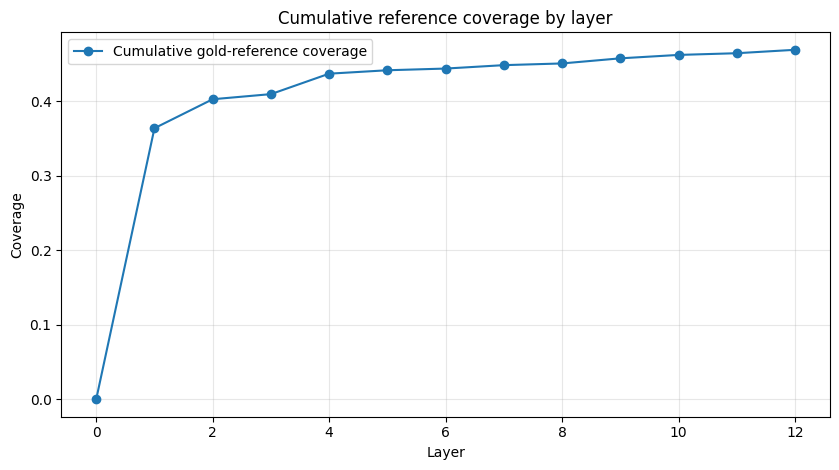

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\cumulative_reference_coverage_by_layer.png


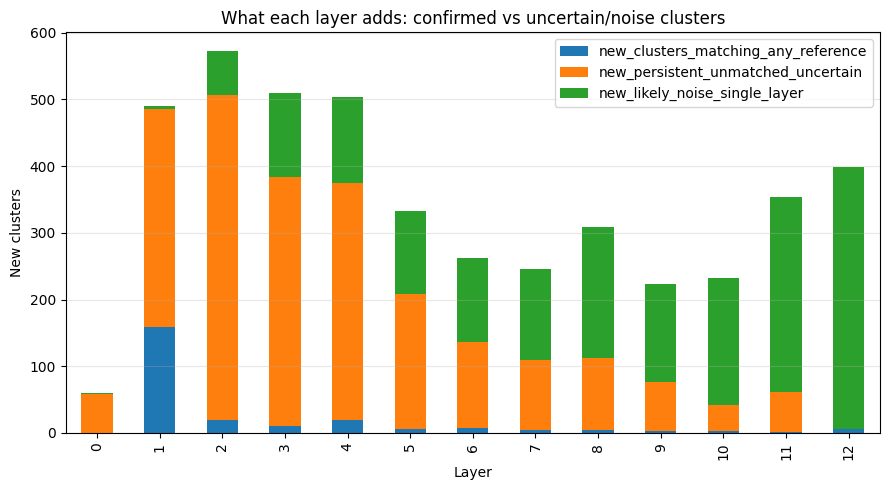

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\marginal_new_information_categories_by_layer.png


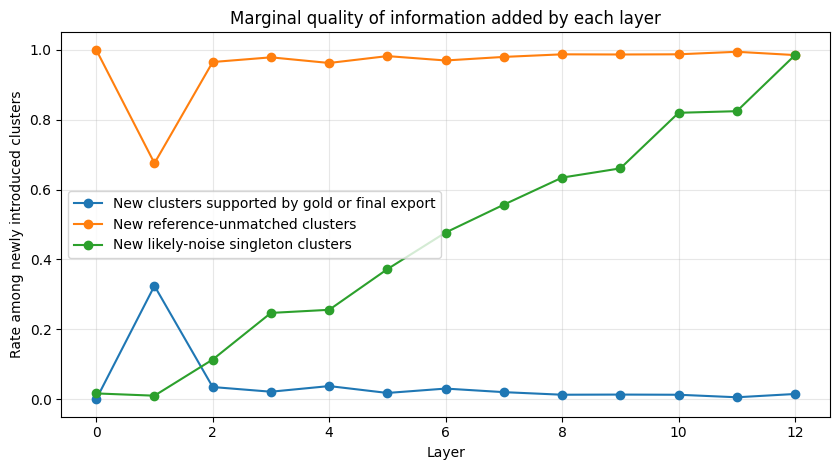

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\marginal_quality_rates_by_layer.png


In [12]:

def save_plot(fig, name):
    out = OUTPUT_DIR / name
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)


# 1. Cumulative alignment with native final export and gold.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    incremental_summary_df["stop_index"],
    incremental_summary_df["cumulative_gold_reference_coverage"],
    marker="o",
    label="Cumulative gold-reference coverage",
)
if len(native_final_triples):
    ax.plot(
        incremental_summary_df["stop_index"],
        incremental_summary_df["cumulative_native_final_reference_coverage"],
        marker="o",
        label="Cumulative native-final coverage",
    )
ax.set_title("Cumulative reference coverage by layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Coverage")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_plot(fig, "cumulative_reference_coverage_by_layer.png")


# 2. New useful vs uncertain/noise clusters per layer.
plot_cols = [
    "new_clusters_matching_any_reference",
    "new_persistent_unmatched_uncertain",
    "new_likely_noise_single_layer",
]
plot_df = incremental_summary_df[["stop_index"] + plot_cols].set_index("stop_index")
fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("What each layer adds: confirmed vs uncertain/noise clusters")
ax.set_xlabel("Layer")
ax.set_ylabel("New clusters")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
save_plot(fig, "marginal_new_information_categories_by_layer.png")


# 3. Marginal supported/noise rates.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    incremental_summary_df["stop_index"],
    incremental_summary_df["marginal_any_reference_supported_rate"],
    marker="o",
    label="New clusters supported by gold or final export",
)
ax.plot(
    incremental_summary_df["stop_index"],
    incremental_summary_df["marginal_uncertain_reference_unmatched_rate"],
    marker="o",
    label="New reference-unmatched clusters",
)
ax.plot(
    incremental_summary_df["stop_index"],
    incremental_summary_df["marginal_likely_noise_rate"],
    marker="o",
    label="New likely-noise singleton clusters",
)
ax.set_title("Marginal quality of information added by each layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Rate among newly introduced clusters")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_plot(fig, "marginal_quality_rates_by_layer.png")


# 4. New native final references first covered.
if len(native_final_triples):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.bar(
        incremental_summary_df["stop_index"],
        incremental_summary_df["new_native_final_references_first_covered"],
    )
    ax.set_title("Native final export facts first introduced by each layer")
    ax.set_xlabel("Layer")
    ax.set_ylabel("New native-final references first covered")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    save_plot(fig, "native_final_references_first_introduced_by_layer.png")


## Compact paper table

In [13]:

paper_cols = [
    "stop_index",
    "layer_name",
    "raw_triples_in_layer",
    "clusters_in_layer",
    "new_clusters_vs_previous_cumulative",
    "reinforced_clusters_seen_before",
    "new_clusters_matching_any_reference",
    "new_uncertain_reference_unmatched",
    "new_likely_noise_single_layer",
    "new_gold_references_first_covered",
    "new_native_final_references_first_covered",
    "cumulative_gold_reference_coverage",
    "cumulative_native_final_reference_coverage",
    "marginal_any_reference_supported_rate",
    "marginal_likely_noise_rate",
]

paper_table = incremental_summary_df[paper_cols].copy()
display(paper_table)

paper_table.to_csv(OUTPUT_DIR / "paper_incremental_layer_contribution_table.csv", index=False)
print("Saved:", OUTPUT_DIR / "paper_incremental_layer_contribution_table.csv")


,stop_index,layer_name,raw_triples_in_layer,clusters_in_layer,new_clusters_vs_previous_cumulative,reinforced_clusters_seen_before,new_clusters_matching_any_reference,new_uncertain_reference_unmatched,new_likely_noise_single_layer,new_gold_references_first_covered,new_native_final_references_first_covered,cumulative_gold_reference_coverage,cumulative_native_final_reference_coverage,marginal_any_reference_supported_rate,marginal_likely_noise_rate
0,0,prefix_stop_after_00_layer00_preprocessing,124,60,60,0,0,60,1,0,0,0.000000,0.0,0.000000,0.016667
1,1,prefix_stop_after_01_layer01_linguistic_expression_extraction,841,538,490,48,159,331,5,159,0,0.363844,0.0,0.324490,0.010204
2,2,prefix_stop_after_02_layer02_candidate_enrichment,1428,1021,572,449,20,552,65,17,0,0.402746,0.0,0.034965,0.113636
3,3,prefix_stop_after_03_layer03_candidate_typing_resolution,1812,1274,510,764,11,499,126,3,0,0.409611,0.0,0.021569,0.247059
4,4,prefix_stop_after_04_layer04_candidate_relation_extraction,2668,1607,504,1103,19,485,129,12,0,0.437071,0.0,0.037698,0.255952
5,5,prefix_stop_after_05_layer05_candidate_triple_generation,2657,1583,333,1250,6,327,124,2,0,0.441648,0.0,0.018018,0.372372
6,6,prefix_stop_after_06_layer06_concept_relation_induction,2742,1609,262,1347,8,254,125,1,0,0.443936,0.0,0.030534,0.477099
7,7,prefix_stop_after_07_layer07_hierarchisation,2642,1561,246,1315,5,241,137,2,0,0.448513,0.0,0.020325,0.556911
8,8,prefix_stop_after_08_layer08_axiom_schemata_extraction,2881,1709,309,1400,4,305,196,1,0,0.450801,0.0,0.012945,0.634304
9,9,prefix_stop_after_09_layer09_general_axiom_extraction,3121,1812,224,1588,3,221,148,3,0,0.457666,0.0,0.013393,0.660714


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\paper_incremental_layer_contribution_table.csv


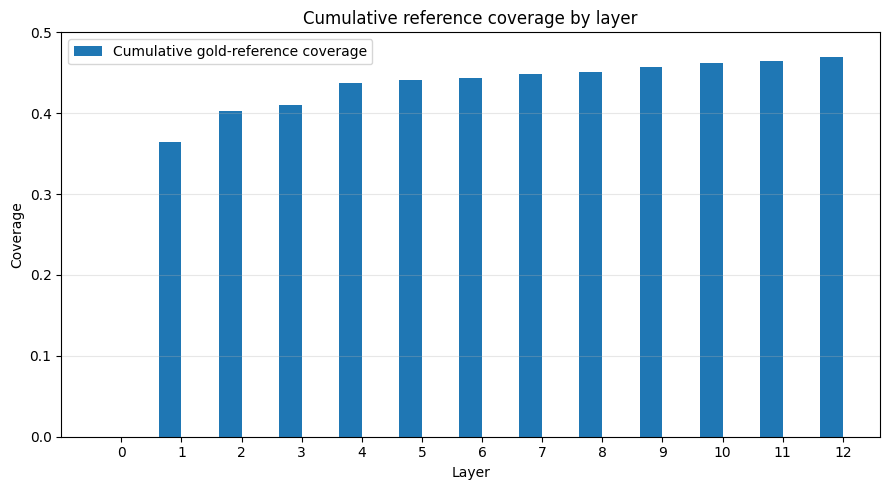

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\hist_cumulative_reference_coverage_by_layer.png


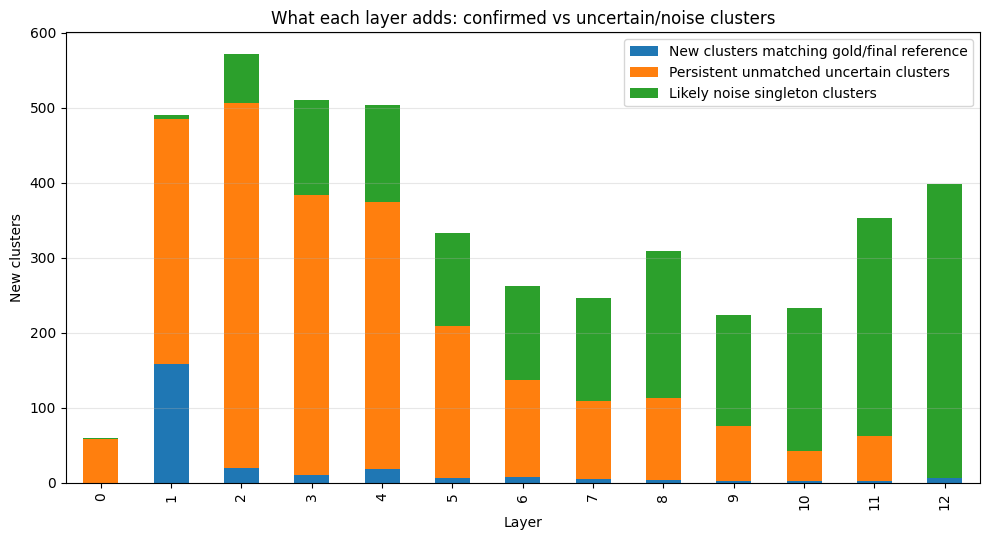

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\hist_marginal_new_information_categories_by_layer.png


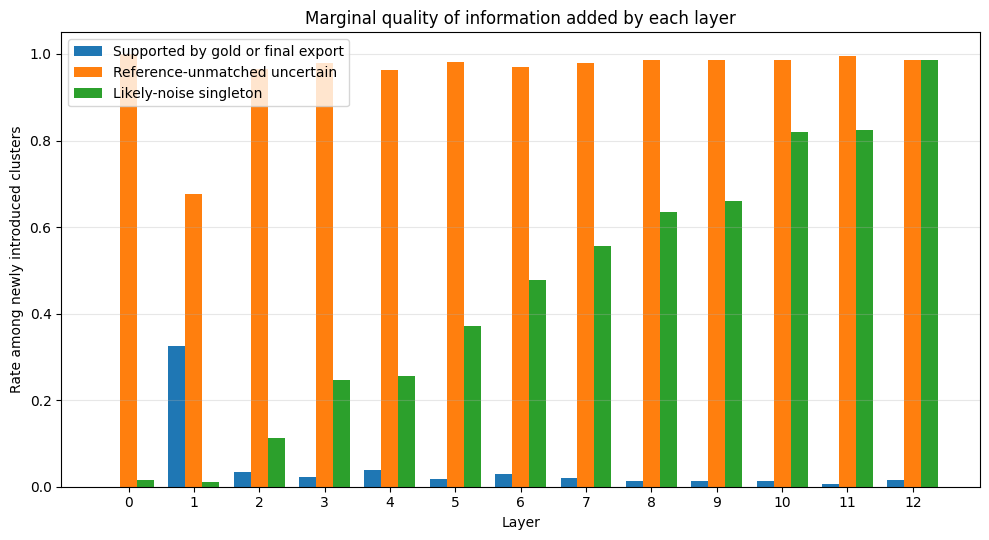

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\hist_marginal_quality_rates_by_layer.png


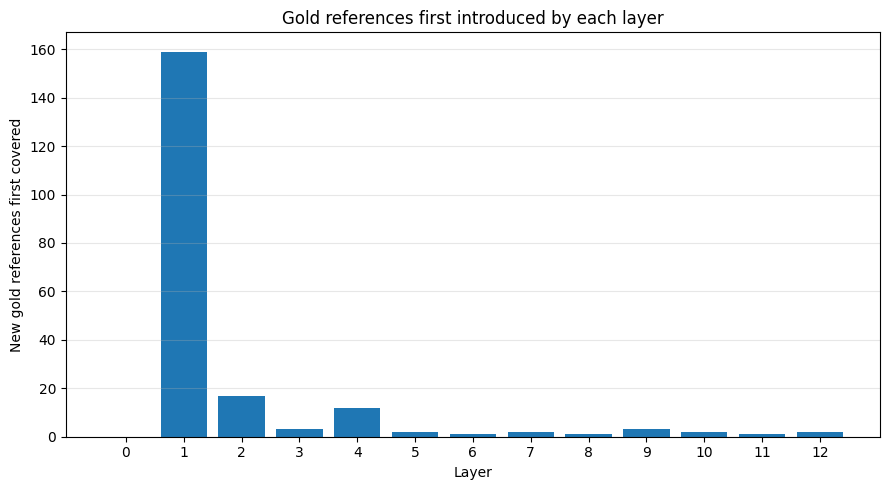

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\incremental_layer_contribution_analysis\hist_gold_references_first_introduced_by_layer.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def save_plot(fig, name):
    out = OUTPUT_DIR / name
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


# =========================================================
# 1. Cumulative coverage as grouped bars
# =========================================================
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(incremental_summary_df))
width = 0.38

ax.bar(
    x - width / 2,
    incremental_summary_df["cumulative_gold_reference_coverage"],
    width,
    label="Cumulative gold-reference coverage",
)

if len(native_final_triples):
    ax.bar(
        x + width / 2,
        incremental_summary_df["cumulative_native_final_reference_coverage"],
        width,
        label="Cumulative native-final coverage",
    )

ax.set_title("Cumulative reference coverage by layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Coverage")
ax.set_xticks(x)
ax.set_xticklabels(incremental_summary_df["stop_index"].astype(int))
ax.set_ylim(0, .5)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

save_plot(fig, "hist_cumulative_reference_coverage_by_layer.png")


# =========================================================
# 2. New useful vs uncertain/noise clusters per layer
# Already histogram-like, keep stacked bars
# =========================================================
plot_cols = [
    "new_clusters_matching_any_reference",
    "new_persistent_unmatched_uncertain",
    "new_likely_noise_single_layer",
]

plot_df = incremental_summary_df[["stop_index"] + plot_cols].set_index("stop_index")

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("What each layer adds: confirmed vs uncertain/noise clusters")
ax.set_xlabel("Layer")
ax.set_ylabel("New clusters")
ax.grid(True, axis="y", alpha=0.3)
ax.legend([
    "New clusters matching gold/final reference",
    "Persistent unmatched uncertain clusters",
    "Likely noise singleton clusters",
])
fig.tight_layout()

save_plot(fig, "hist_marginal_new_information_categories_by_layer.png")


# =========================================================
# 3. Marginal supported/noise rates as grouped bars
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(incremental_summary_df))
width = 0.26

ax.bar(
    x - width,
    incremental_summary_df["marginal_any_reference_supported_rate"],
    width,
    label="Supported by gold or final export",
)

ax.bar(
    x,
    incremental_summary_df["marginal_uncertain_reference_unmatched_rate"],
    width,
    label="Reference-unmatched uncertain",
)

ax.bar(
    x + width,
    incremental_summary_df["marginal_likely_noise_rate"],
    width,
    label="Likely-noise singleton",
)

ax.set_title("Marginal quality of information added by each layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Rate among newly introduced clusters")
ax.set_xticks(x)
ax.set_xticklabels(incremental_summary_df["stop_index"].astype(int))
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

save_plot(fig, "hist_marginal_quality_rates_by_layer.png")


# =========================================================
# 4. New native-final references first covered by each layer
# =========================================================
if len(native_final_triples):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        incremental_summary_df["stop_index"].astype(int),
        incremental_summary_df["new_native_final_references_first_covered"],
    )

    ax.set_title("Native final export facts first introduced by each layer")
    ax.set_xlabel("Layer")
    ax.set_ylabel("New native-final references first covered")
    ax.set_xticks(incremental_summary_df["stop_index"].astype(int))
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    save_plot(fig, "hist_native_final_references_first_introduced_by_layer.png")


# =========================================================
# 5. Optional: new gold references first covered by each layer
# =========================================================
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    incremental_summary_df["stop_index"].astype(int),
    incremental_summary_df["new_gold_references_first_covered"],
)

ax.set_title("Gold references first introduced by each layer")
ax.set_xlabel("Layer")
ax.set_ylabel("New gold references first covered")
ax.set_xticks(incremental_summary_df["stop_index"].astype(int))
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

save_plot(fig, "hist_gold_references_first_introduced_by_layer.png")


## Interpretation guide

Use this notebook to support a claim like:

> Rather than measuring whether each layer directly increases final F1, we measure what information each layer introduces into the cumulative evidence pool. Later layers may add fewer new gold facts, but they may reinforce, normalize, or make final-output facts recoverable. Reference-unmatched additions are treated as uncertain; if they appear in only one layer and are not aligned with gold or the native final export, they are counted as likely noise.

Recommended terms:

- **Confirmed new information**: a newly introduced cluster that aligns with gold or the native NeoOLAF final export.
- **Native-final aligned information**: information that appears in the final NeoOLAF export and is first recoverable from a given layer.
- **Uncertain information**: newly introduced cluster not matched to gold or final export.
- **Likely noise**: uncertain cluster that appears in only one layer and is never reinforced later.

Important: “likely noise” is not a manually verified false positive. It is a reference-based diagnostic category.
